In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")
sns.set_theme()


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [110]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Data Cleaning**

In [111]:
# Remove missing customers
df = df.dropna(subset=["CustomerID"])

# Remove cancelled/negative transactions
df = df[df["Quantity"] > 0]

# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.shape

(397924, 9)

**Define Observation & Prediction Windows**

In [112]:
split_date = "2011-06-30"

observation = df[df["InvoiceDate"] <= split_date]
prediction = df[df["InvoiceDate"] > split_date]

**Create RFM Features (Observation Period Only)**

In [113]:
reference_date = observation["InvoiceDate"].max()

recency = observation.groupby("CustomerID")["InvoiceDate"].max()
recency = (reference_date - recency).dt.days

frequency = observation.groupby("CustomerID")["InvoiceNo"].nunique()
monetary = observation.groupby("CustomerID")["Revenue"].sum()
avg_order = monetary / frequency

first_purchase = observation.groupby("CustomerID")["InvoiceDate"].min()
tenure = (reference_date - first_purchase).dt.days

total_quantity = observation.groupby("CustomerID")["Quantity"].sum()

In [114]:
obs_sorted = observation.sort_values(["CustomerID", "InvoiceDate"])

obs_sorted["PrevDate"] = obs_sorted.groupby("CustomerID")["InvoiceDate"].shift(1)
obs_sorted["Gap"] = (obs_sorted["InvoiceDate"] - obs_sorted["PrevDate"]).dt.days

avg_gap = obs_sorted.groupby("CustomerID")["Gap"].mean()
std_gap = obs_sorted.groupby("CustomerID")["Gap"].std()

In [115]:
mid_date = observation["InvoiceDate"].min() + \
           (reference_date - observation["InvoiceDate"].min()) / 2

first_half = observation[observation["InvoiceDate"] <= mid_date]
second_half = observation[observation["InvoiceDate"] > mid_date]

freq_first = first_half.groupby("CustomerID")["InvoiceNo"].nunique()
freq_second = second_half.groupby("CustomerID")["InvoiceNo"].nunique()

momentum = freq_second - freq_first

In [116]:
features = pd.concat([
    recency,
    frequency,
    monetary,
    avg_order,
    tenure,
    total_quantity,
    avg_gap,
    std_gap,
    momentum
], axis=1)

features.columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "Tenure",
    "TotalQuantity",
    "AvgGap",
    "StdGap",
    "Momentum"
]

features = features.fillna(0)

**Feature Importance Plot**

<BarContainer object of 9 artists>

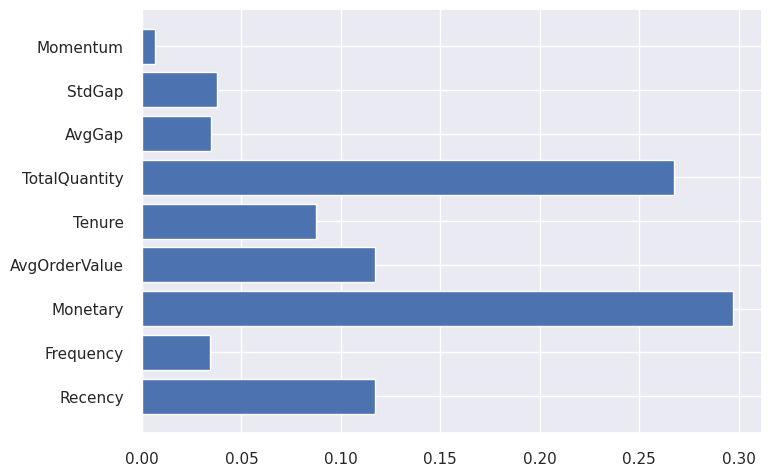

In [117]:
importance = rf.feature_importances_
plt.barh(X.columns, importance)

**Correlation Heatmap**

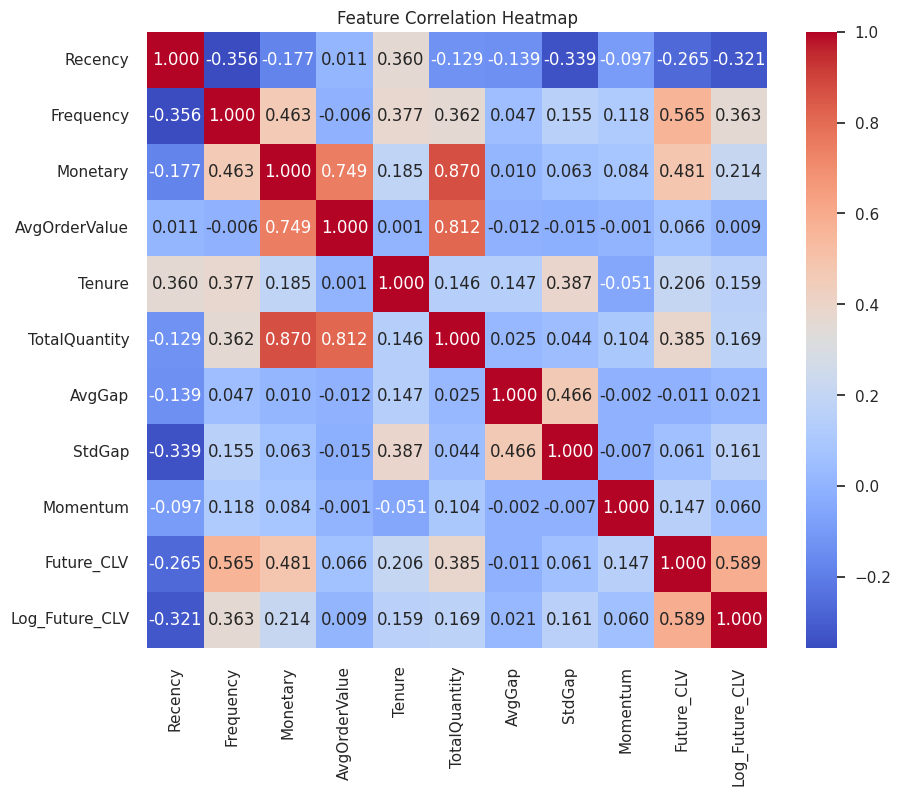

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Distribution count of RFM**

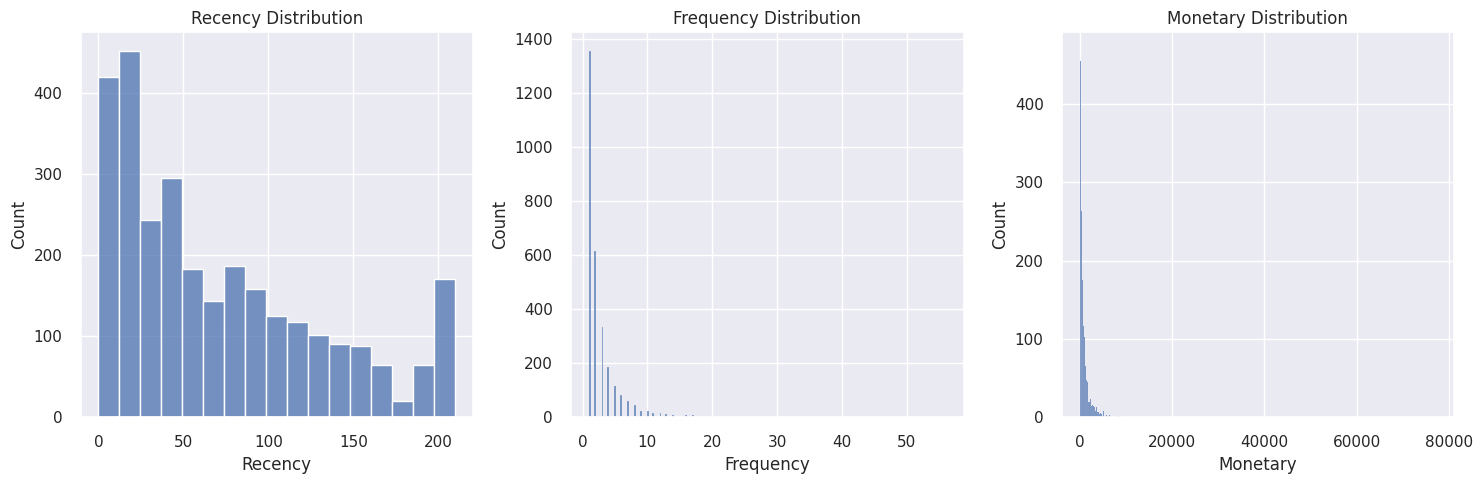

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(data["Recency"], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(data["Frequency"], ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(data["Monetary"], ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

**Transaction Volume Over Time**

<Axes: xlabel='InvoiceDate'>

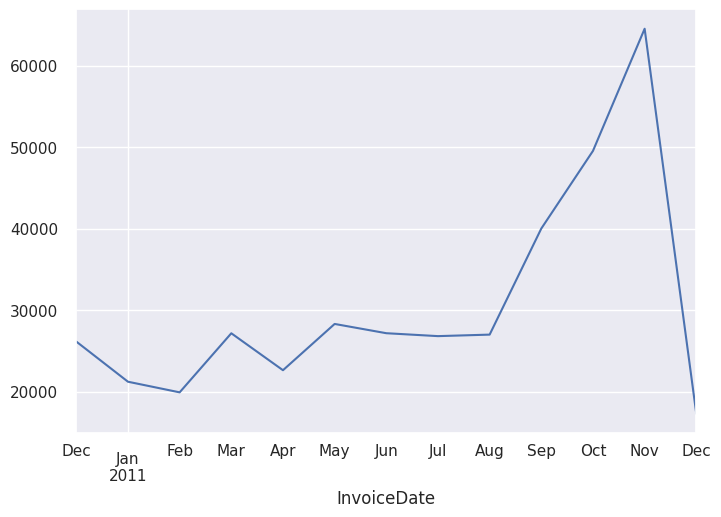

In [120]:
monthly_transactions = df.groupby(df["InvoiceDate"].dt.to_period("M")).size()
monthly_transactions.plot()

**Monthly Revenue Trend**

<Axes: xlabel='InvoiceDate'>

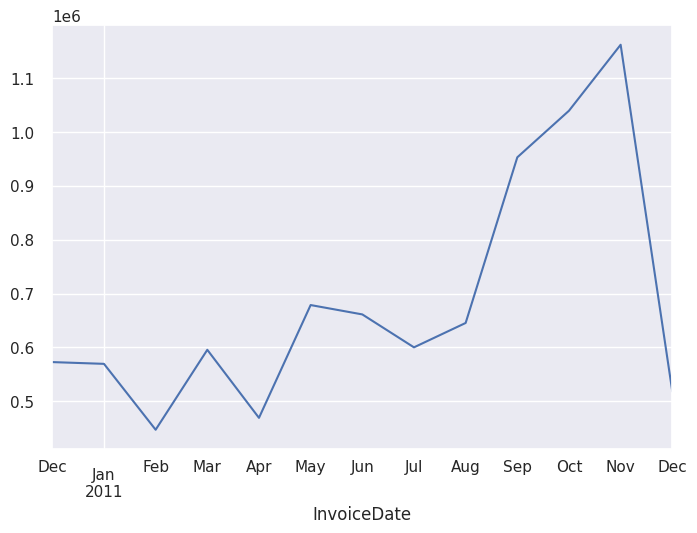

In [121]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_revenue.plot()

**Create Future CLV (Target Variable)**

In [122]:
future_clv = prediction.groupby("CustomerID")["Revenue"].sum()
future_clv = future_clv.rename("Future_CLV")

data = features.merge(future_clv, on="CustomerID", how="left")
data["Future_CLV"] = data["Future_CLV"].fillna(0)

In [123]:
upper_limit = data["Future_CLV"].quantile(0.99)
data = data[data["Future_CLV"] <= upper_limit]

In [124]:
data["Log_Future_CLV"] = np.log1p(data["Future_CLV"])

**Prepare Training Data**

In [125]:
X = data.drop(["Future_CLV", "Log_Future_CLV"], axis=1)
y = data["Log_Future_CLV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Traditional RFM-Based Estimation (Baseline)**

In [126]:
rfm_pred_log = np.log1p(X_test["Monetary"])

rfm_mae = mean_absolute_error(y_test, rfm_pred_log)
rfm_rmse = np.sqrt(mean_squared_error(y_test, rfm_pred_log))
rfm_r2 = r2_score(y_test, rfm_pred_log)

**Linear Regression**

In [127]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

**Random Forest**

In [128]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)



**XGBoost**

In [129]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

**Create Final Comparison Table**

In [130]:
results = pd.DataFrame({
    "Model": ["RFM Baseline", "Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [rfm_mae, lr_mae, rf_mae, xgb_mae],
    "RMSE": [rfm_rmse, lr_rmse, rf_rmse, xgb_rmse],
    "R2": [rfm_r2, lr_r2, rf_r2, xgb_r2]
})
results = results.round(2)
results

,Model,MAE,RMSE,R2
0,RFM Baseline,2.33,3.42,-0.11
1,Linear Regression,2.51,2.85,0.23
2,Random Forest,2.40,2.83,0.25
3,XGBoost,2.43,2.93,0.19


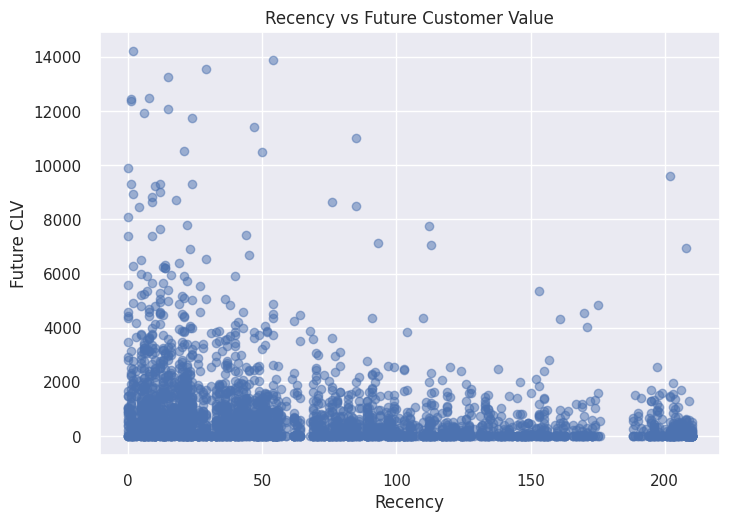

In [131]:
plt.scatter(data["Recency"], data["Future_CLV"], alpha=0.5)

plt.xlabel("Recency")
plt.ylabel("Future CLV")
plt.title("Recency vs Future Customer Value")

plt.show()